In [137]:
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap

from xgboost import XGBClassifier
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_recall_curve, f1_score, classification_report, 
                             confusion_matrix, roc_curve, auc, precision_score, recall_score, 
                             RocCurveDisplay, make_scorer, average_precision_score)

# Load Model

In [3]:
xgb_model = joblib.load('best_xgboost_model.pkl')
X_test = pd.read_csv('Dataset/X_test.csv')
y_test = pd.read_csv('Dataset/y_test.csv')

# Find best threshold

In [75]:
beta = 2.0
y_proba = xgb_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
fbeta_scores = ((1 + beta**2) * precision * recall) / (beta**2 * precision + recall + 1e-9)

**default threshold**

In [62]:
y_pred = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.49      0.98      0.66      1643

    accuracy                           1.00    554082
   macro avg       0.75      0.99      0.83    554082
weighted avg       1.00      1.00      1.00    554082

[[550792   1647]
 [    38   1605]]


**using ROC**

In [63]:
tpr, fpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
y_pred_roc = (y_proba >= roc_auc).astype(int)
print(classification_report(y_test, y_pred_roc))
print(confusion_matrix(y_test, y_pred_roc))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    552439
           1       0.03      1.00      0.07      1643

    accuracy                           0.92    554082
   macro avg       0.52      0.96      0.51    554082
weighted avg       1.00      0.92      0.95    554082

[[507112  45327]
 [     4   1639]]


**Using F1-score and F_beta-score**

In [78]:
idx_f1 = np.argmax(f1_scores[:-1])
idx_fbeta = np.argmax(fbeta_scores[:-1])
print(f"Best F1 Score: {f1_scores[idx_f1]:.4f} at threshold {thresholds[idx_f1]:.4f}")
print(f"Best F-beta Score: {fbeta_scores[idx_fbeta]:.4f} at threshold {thresholds[idx_fbeta]:.4f}")

Best F1 Score: 0.9040 at threshold 0.9890
Best F-beta Score: 0.8964 at threshold 0.9561


In [79]:
print('classification_report at F1 threshold:')
y_pred_f1 = (y_proba >= thresholds[idx_f1]).astype(int)
print(classification_report(y_test, y_pred_f1))
print('confusion_matrix at F1 threshold:')
print(confusion_matrix(y_test, y_pred_f1))

print('\n\nclassification_report at F-beta threshold:')
y_pred_fbeta = (y_proba >= thresholds[idx_fbeta]).astype(int)
print(classification_report(y_test, y_pred_fbeta))
print('confusion_matrix at F-beta threshold:')
print(confusion_matrix(y_test, y_pred_fbeta))

classification_report at F1 threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.96      0.85      0.90      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.93      0.95    554082
weighted avg       1.00      1.00      1.00    554082

confusion_matrix at F1 threshold:
[[552387     52]
 [   245   1398]]


classification_report at F-beta threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.84      0.91      0.88      1643

    accuracy                           1.00    554082
   macro avg       0.92      0.96      0.94    554082
weighted avg       1.00      1.00      1.00    554082

confusion_matrix at F-beta threshold:
[[552158    281]
 [   146   1497]]


**Cost-Benefit Analysis**

In [99]:
FP_cost = 1
FN_cost = 5

optimal_threshold = 0.0
min_cost = float('inf')

for thresh in np.arange(0.0, 1.01, 0.001):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    total_cost = fp * FP_cost + fn * FN_cost

    if total_cost < min_cost:
        min_cost = total_cost
        optimal_threshold = thresh
        
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Minimum cost: ${min_cost}")

Optimal threshold: 0.956
Minimum cost: $1012


In [100]:
y_pred_cost = (y_proba >= optimal_threshold).astype(int)
print('\n\nclassification_report at cost-based threshold:')
print(classification_report(y_test, y_pred_cost))
print('confusion_matrix at cost-based threshold:')
print(confusion_matrix(y_test, y_pred_cost))



classification_report at cost-based threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.84      0.91      0.87      1643

    accuracy                           1.00    554082
   macro avg       0.92      0.96      0.94    554082
weighted avg       1.00      1.00      1.00    554082

confusion_matrix at cost-based threshold:
[[552157    282]
 [   146   1497]]


# Compairation Thresholds

In [104]:
default_threshold = 0.5
pr_auc_threshold = roc_auc
f1_threshold = thresholds[idx_f1]
fbeta_threshold = thresholds[idx_fbeta]
cost_threshold = optimal_threshold

thresholds_dict = {
    'Default (0.5)': default_threshold,
    'ROC AUC': pr_auc_threshold,
    'Best F1': f1_threshold,
    'Best F-beta': fbeta_threshold,
    'Cost-based': cost_threshold
}

results_list = []

for name, t in thresholds_dict.items():
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results_list.append({
        'Name': name,
        'Threshold': t,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })
df_results = pd.DataFrame(results_list)
df_results.head()

,Name,Threshold,Precision,Recall,F1 Score,TP,FP,TN,FN
0,Default (0.5),0.500000,0.493542,0.976872,0.655771,1605,1647,550792,38
1,ROC AUC,0.001514,0.034898,0.997565,0.067436,1639,45327,507112,4
2,Best F1,0.989016,0.964138,0.850883,0.903977,1398,52,552387,245
3,Best F-beta,0.956087,0.841957,0.911138,0.875183,1497,281,552158,146
4,Cost-based,0.956000,0.841484,0.911138,0.874927,1497,282,552157,146


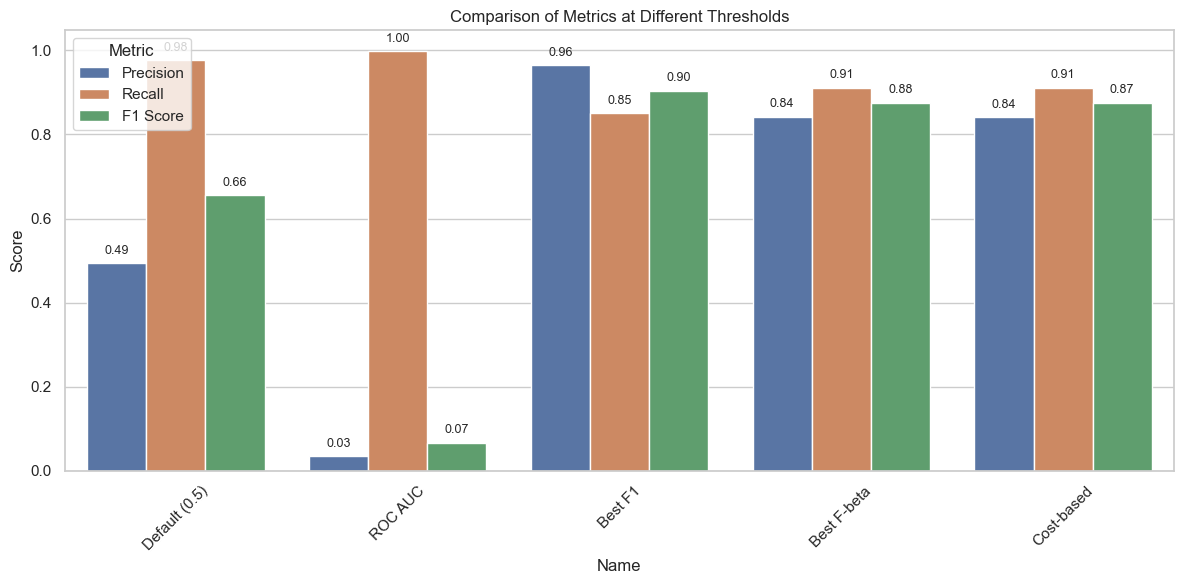

In [116]:
df_metrics_melted = df_results.melt(
    id_vars='Name', 
    value_vars=['Precision', 'Recall', 'F1 Score'], # Các metrics bạn muốn so sánh
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12, 6))
plot = sns.barplot(data=df_metrics_melted, x='Name', y='Score', hue='Metric')
plt.title('Comparison of Metrics at Different Thresholds')
plt.xticks(rotation=45)
plt.legend(title='Metric')
for p in plot.patches:
    if p.get_height() > 0: 
        plot.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=9)
plt.tight_layout()
plt.show()

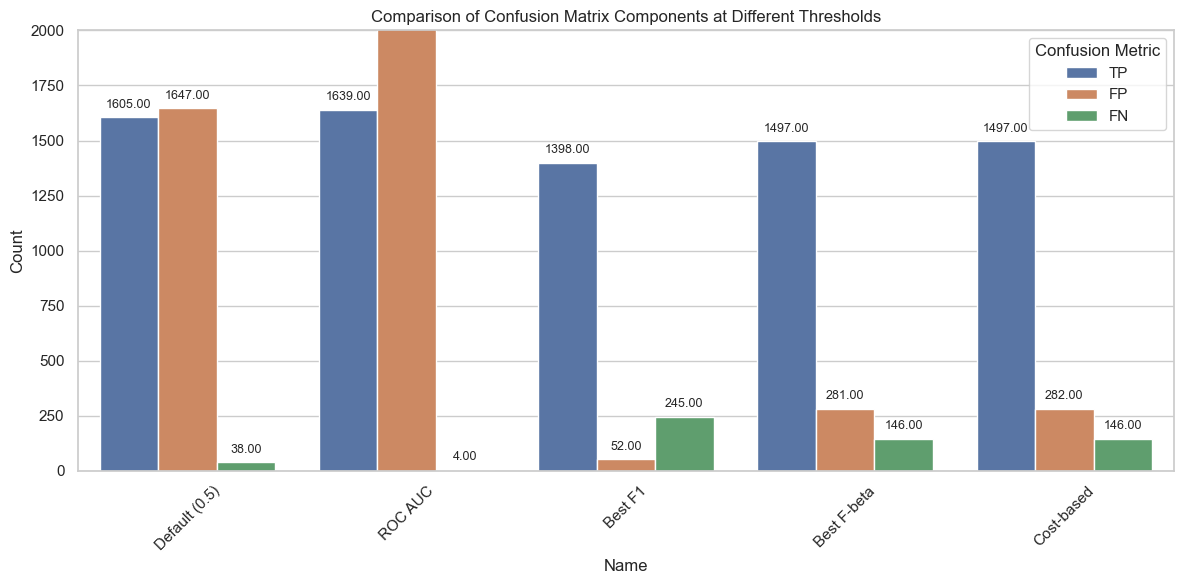

In [118]:
df_confusion = df_results[['Name', 'TP', 'FP', 'TN', 'FN']].copy()
df_confusion_melted = df_confusion.melt(
    id_vars='Name', 
    value_vars=['TP', 'FP', 'FN'], 
    var_name='Confusion Metric', 
    value_name='Count'
)
plt.figure(figsize=(12, 6))
plot = sns.barplot(data=df_confusion_melted, x='Name', y='Count', hue='Confusion Metric')
plt.title('Comparison of Confusion Matrix Components at Different Thresholds')
plt.xticks(rotation=45)
plt.ylim(0, 2000)
plt.legend(title='Confusion Metric')
for p in plot.patches:
    if p.get_height() > 0: 
        plot.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=9)
plt.tight_layout()
plt.show()

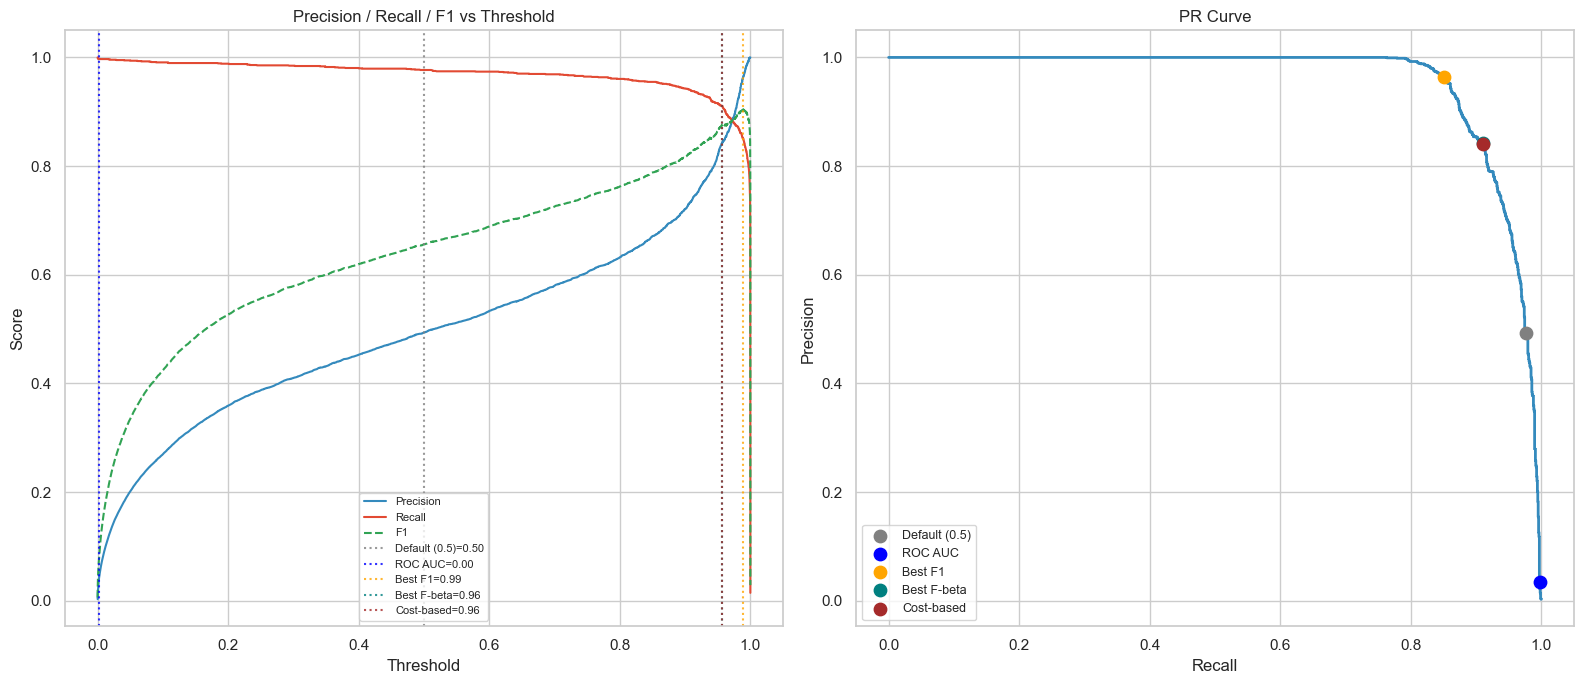

In [ ]:
p_curve, r_curve, t_curve = precision_recall_curve(y_test, y_proba)
f1_curve = 2 * (p_curve * r_curve) / (p_curve + r_curve + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")

ax1.plot(t_curve, p_curve[:-1], label='Precision', color='#348abd')
ax1.plot(t_curve, r_curve[:-1], label='Recall', color='#e24a33')
ax1.plot(t_curve, f1_curve[:-1], label='F1', color='#31a354', linestyle='--')

colors = ['gray', 'blue', 'orange', 'teal', 'brown']
for (name, t_val), col in zip(thresholds_dict.items(), colors):
    ax1.axvline(t_val, color=col, linestyle=':', alpha=0.8, label=f'{name}={t_val:.2f}')

ax1.set_title('Precision / Recall / F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.legend(fontsize=8, loc='lower center')
ax2.plot(r_curve, p_curve, color='#348abd', lw=2)

for (name, t_val), col in zip(thresholds_dict.items(), colors):
    idx = np.argmin(np.abs(t_curve - t_val))
    ax2.scatter(r_curve[idx], p_curve[idx], color=col, s=80, label=name, zorder=5)

ax2.set_title('PR Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# XAI with  SHAP

In [29]:
classifier = xgb_model.named_steps['classifier']

idx_sample = np.random.choice(len(X_test), size=50000, replace=False)
X_sample = X_test.iloc[idx_sample]
y_sample = y_test.iloc[idx_sample]

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)
feature_names = X_sample.columns
top_features = feature_names[np.argmax(np.abs(shap_values).mean(axis=0))]

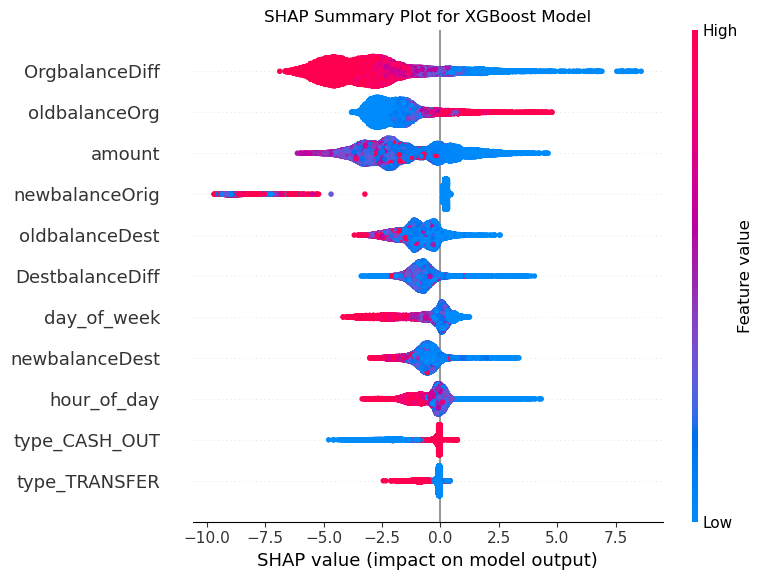

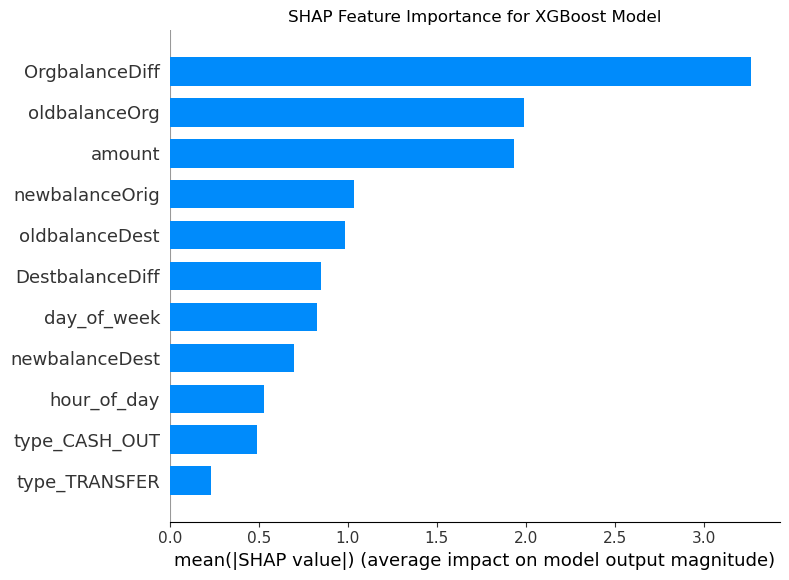

<Figure size 1000x600 with 0 Axes>

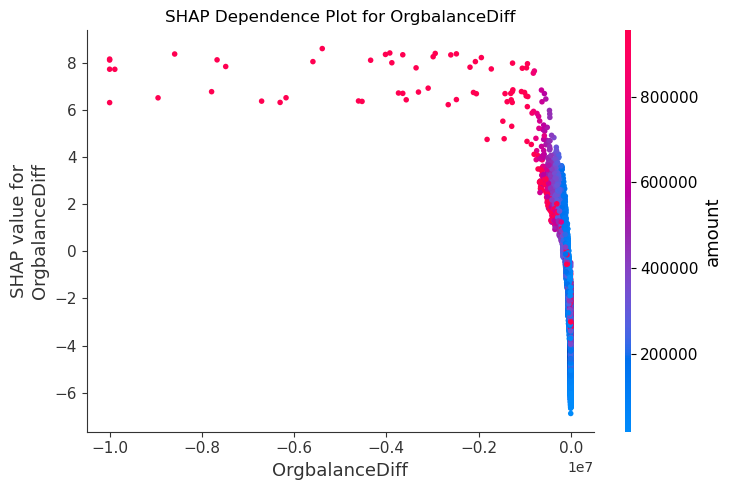

In [30]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot for XGBoost Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance for XGBoost Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_features, shap_values, X_sample, feature_names=feature_names, interaction_index="auto", show=False)
plt.title(f'SHAP Dependence Plot for {top_features}')
plt.tight_layout()
plt.show()